In [1]:
import pandas as pd
import os, sys, pickle

sys.path.insert(0,'..')
from functions.myfunctions import *
import functions.distancefunctions as df
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
distances_dir = '../data/outputs/'
f2 = '../data/output/figures/'

datalist1 = pd.read_csv('../data/tcrdb_export_cleaned_withseqs.csv', index_col=0).drop_duplicates(subset = ['pdb'], keep='first')

In [3]:
with open(distances_dir + 'interchain_mindists.pickle', 'rb') as handle:
    distances = pickle.load(handle)
    
with open(distances_dir + 'intrachain_a_mindists.pickle', 'rb') as handle:
    distances_a = pickle.load(handle)

with open(distances_dir + 'intrachain_b_mindists.pickle', 'rb') as handle:
    distances_b = pickle.load(handle)

In [4]:
cdr1_res = list(range(27, 39))
cdr1_res = [str(x) for x in cdr1_res]
cdr2_res = list(range(56, 66))
cdr2_res = [str(x) for x in cdr2_res]
cdr3_res = list(range(105,112)) + ['111A', '111B',
                        '111C', '111D', '111E', '111F', '112E', '112F', '112D', '112C', '112B', '112A', '112'] + list(range(113,118))
cdr3_res = [str(x) for x in cdr3_res]

Number of contacts at different thresholds

In [5]:
thresh = np.arange(2, 10.5, 0.5)
print(thresh)

thresh_contact_count_interchain = {}
thresh_contact_count_intrachain_a = {}
thresh_contact_count_intrachain_b = {}

for t in thresh:
    thresh_contact_count_interchain[t] = []
    thresh_contact_count_intrachain_a[t] = []
    thresh_contact_count_intrachain_b[t] = []
    
    for pdb in datalist1['pdb'].tolist():
        d_pdb = distances[pdb]
        pdb_3_3 = [x for x in d_pdb.keys() if (x[0] in cdr3_res) and (x[1] in cdr3_res) and (d_pdb[x] < t)]

        thresh_contact_count_interchain[t].append(len(pdb_3_3))

        d_pdb_a = distances_a[pdb]
        d_pdb_b = distances_b[pdb]
        pdb_1_3_a = [x for x in d_pdb_a.keys() if (x[0] in cdr1_res) and (x[1] in cdr3_res) and (d_pdb_a[x] < t)]
        pdb_1_3_b = [x for x in d_pdb_b.keys() if (x[0] in cdr1_res) and (x[1] in cdr3_res) and (d_pdb_b[x] < t)]

        thresh_contact_count_intrachain_a[t].append(len(pdb_1_3_a))
        thresh_contact_count_intrachain_b[t].append(len(pdb_1_3_b))

[ 2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5
  9.   9.5 10. ]


[0.0029411764705882353, 0.09117647058823529, 0.7823529411764706, 2.6882352941176473, 5.0588235294117645, 6.426470588235294, 8.214705882352941, 10.123529411764705, 12.58235294117647, 16.055882352941175, 20.66470588235294, 26.179411764705883, 31.970588235294116, 38.22941176470588, 44.358823529411765, 51.16470588235294, 57.96470588235294]


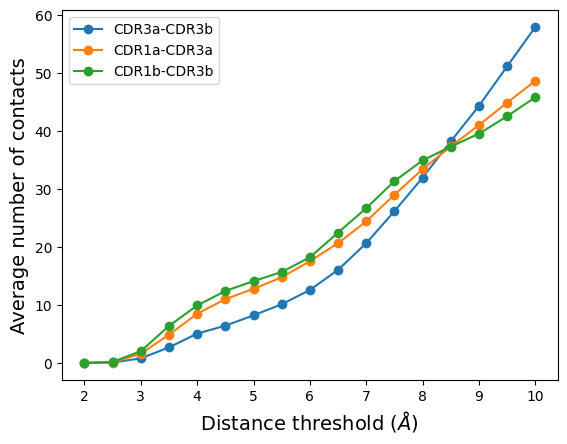

In [6]:
vals_inter = [np.mean(thresh_contact_count_interchain[t]) for t in thresh]
vals_intra_a = [np.mean(thresh_contact_count_intrachain_a[t]) for t in thresh]
vals_intra_b = [np.mean(thresh_contact_count_intrachain_b[t]) for t in thresh]
print(vals_inter)

plt.plot(thresh, vals_inter, marker = 'o', label = 'CDR3a-CDR3b')
plt.plot(thresh, vals_intra_a, marker = 'o', label = 'CDR1a-CDR3a')
plt.plot(thresh, vals_intra_b, marker = 'o', label = 'CDR1b-CDR3b')
plt.xlabel(r'Distance threshold ($\AA$)', fontsize = 14)
plt.ylabel('Average number of contacts', fontsize = 14)
plt.legend()
plt.savefig(f2 + 'number_of_contacts_vs_threshold.pdf', bbox_inches = 'tight')
plt.show()